In [84]:
import pandas as pd
import numpy as np
import plotly.express as px
from scipy.stats import chi2_contingency

In [22]:
nsch = pd.read_sas("nsch_2024_topical_SAS/nsch_2024e_topical.sas7bdat")

In [23]:
nsch_filtered = nsch[[
    'FWC',            # Selected Child Weight (Operational)
    'EVERHOMELESS',   # SINCE this child WAS BORN, have they ever been homeless or lived in a shelter?
#    'SC_AGE_YEARS',   # Age of Selected Child - In Years (S1)
#    'SC_AGE_LT10',    # Age Recode: Child Under 10 Years Old (S1)
#    'SC_AGE_LT9',     # Age Recode: Child Under 9 Years Old (S1)
#    'SC_AGE_LT6',     # Age Recode: Child Under 6 Years Old (S1)
#    'SC_AGE_LT4',     # Age Recode: Child Under 4 Years Old (S1)
    'SC_RACE_R',      # Race of Selected Child - Recode (S1)
#    'SC_SEX',         # Sex of Selected Child (S1)
#    'TOTKIDS_R',      # Total Number of Children in Household - Recode
    'BORNUSA',        # Was Selected Child Born in the US? (S1)
#    'LIVEUSA_MO',     # Months Selected Child Has Lived in the US
#    'LIVEUSA_YR',     # Years Selected Child Has Lived in the US
    'SC_ENGLISH',     # Primary Language Spoken at Home / English Ability (S1)
#    'MOVES',          # How Many Times Child Has Moved Places Lived
    'GRADES',         # Child's Overall School Performance / Grades (A, B, C, etc.)
    'K7Q82_R',        # Cares About Doing Well in School (T2 T3)
    'K7Q83_R',        # Does All Required Homework (T2 T3)
#    'K11Q43R',        # How Many Times Moved to New Address (T1 T2 T3)
#    'K11Q61',         # Food Stamps - Past 12 Months (T1 T2 T3)
    'K2Q01',          # General Health Status of Child (Excellent to Poor)
#    'FAMILY_R',       # Family Structure / Household Type - Recode
#    'FIPSST',         # FIPS State Code (State of Residence)
#    'S9Q34',          # WIC Benefits - Past 12 Months (T1 T2 T3)
#    'A1_EMPLOYED_R',  # Adult 1 Employment Status - Recode
#    'A2_EMPLOYED_R',  # Adult 2 Employment Status - Recode
#    'A1_MARITAL',     # Adult 1 Marital Status
#    'A1_BORN',        # Was Adult 1 Born in the US?
#    'A1_AGE',         # Age of Adult 1
#    'A2_BORN',        # Was Adult 2 Born in the US?
#    'A2_AGE'          # Age of Adult 2
    'SC_HISPANIC_R'   # Hispanic Origin of Selected Child, Recode (S1)
]].copy()

In [25]:
column_mapping = {
    'EVERHOMELESS': 'Homeless_Status',
    'GRADES': 'School_Performance',
    'K2Q01': 'General_Health',
    'SC_RACE_R': 'Child_Race',
    'FWC': 'Weight', 
    'SC_ENGLISH': 'Primary Language Spoken at Home / English Ability',
    'BORNUSA': 'Was Selected Child Born in the US?',
    'SC_HISPANIC_R': 'Hispanic, Latino, or Spanish origin?',
    'K7Q82_R': 'Cares About Doing Well in School',
    'K7Q83_R': 'Does All Required Homework'
}

colmap = nsch_filtered.rename(columns=column_mapping).copy()

value_maps = {
    'Homeless_Status': {
        1: 'Homeless',
        2: 'Non-Homeless'
    },
    'School_Performance': {
    1: "Mostly A's",
    2: "Mostly A's and B's",
    3: "Mostly B's and C's",
    4: "Mostly C's and D's",
    5: "Mostly D's or lower",
    6: "This child's school does not give these grades"
    },
    'General_Health': {
        1: 'Excellent',
        2: 'Very Good',
        3: 'Good',
        4: 'Fair',
        5: 'Poor'
    },
    'Child_Race': {
        1: 'White Alone',
        2: 'Black or African American Alone',
        3: 'American Indian or Alaska Native Alone',
        4: 'Asian Alone',
        5: 'Native Hawaiian and Other Pacific Islander Alone',
        6: 'Some Other Race Alone',
        7: 'Two or More Races'
    },
    'Primary Language Spoken at Home / English Ability': {
        1: 'English',
        2: 'Spanish',
        3: 'Other Language'
    },
    'Was Selected Child Born in the US?': {
        1: 'Yes',
        2: 'No'
    },
    'Hispanic, Latino, or Spanish origin?':{
        1: 'Yes',
        2: 'No'
    },
    'Cares About Doing Well in School': {
        1: 'Always',
        2: 'Usually',
        3: 'Sometimes',
        4: 'Never'
    },   
    'Does All Required Homework': {
        1: 'Always',
        2: 'Usually',
        3: 'Sometimes',
        4: 'Never'
    }
}

for col, val in value_maps.items():
    colmap[col] = colmap[col].map(val)

In [109]:
def plotfeature(
    df,
    feature,
    title
):
        clean = df[df[feature].notnull()].copy() #remove nan
        weighted = clean.groupby(['Homeless_Status', feature])['Weight'].sum().reset_index() #group by homeless status and feature and add weights
    group_totals = weighted.groupby(['Homeless_Status'])['Weight'].transform('sum') #generate total weights for homeless/nonhomeless
    weighted['Percentage'] = (weighted['Weight'] / group_totals) * 100 #generate percentages

    #crosstabulate and perform chisquare
    contingency = pd.crosstab(df['Homeless_Status'], df[feature])
    print(contingency)
    
    chi2_stat, p_val, dof, expected_freq = chi2_contingency(contingency)
    print(f'\nChi-Square Statistic: {chi2_stat:.2f}')
    print(f'\np-value: {p_val:.2e}')

    
    #make dictionary to set order of values plotted
    orders = {} 
    orders[feature] = list(value_maps[feature].values())
    orders['Homeless_Status'] = ['Non-Homeless', 'Homeless']

    #plot figure
    fig = px.bar(
    weighted,
    x=feature,
    y='Percentage',
    color='Homeless_Status',
    category_orders=orders,
    barmode='group',
    text_auto='.1f',  # Displays percentages on top of bars rounded to 1 decimal
    title=title,
    labels={
        'Percentage': 'Weighted Percentage (%)'
    }
    )
    
    max_pct = weighted['Percentage'].max() if not weighted.empty else 100
    fig.update_traces(textposition='outside')
    fig.update_layout(
        xaxis_title=None,
        yaxis=dict(ticksuffix='%', range=[0, min(100, max_pct + 12)]),
        template='plotly_white',
        height=500,
        width=900
    )
    
    # Display the interactive plot
    fig.show()

   Homeless_Status                              School_Performance  \
0         Homeless                                      Mostly A's   
1         Homeless                              Mostly A's and B's   
2         Homeless                              Mostly B's and C's   
3         Homeless                              Mostly C's and D's   
4         Homeless                             Mostly D's or lower   
5         Homeless  This child's school does not give these grades   
6     Non-Homeless                                      Mostly A's   
7     Non-Homeless                              Mostly A's and B's   
8     Non-Homeless                              Mostly B's and C's   
9     Non-Homeless                              Mostly C's and D's   
10    Non-Homeless                             Mostly D's or lower   
11    Non-Homeless  This child's school does not give these grades   

          Weight  Percentage  
0   1.864066e+05   11.907638  
1   5.731827e+05   36.61486

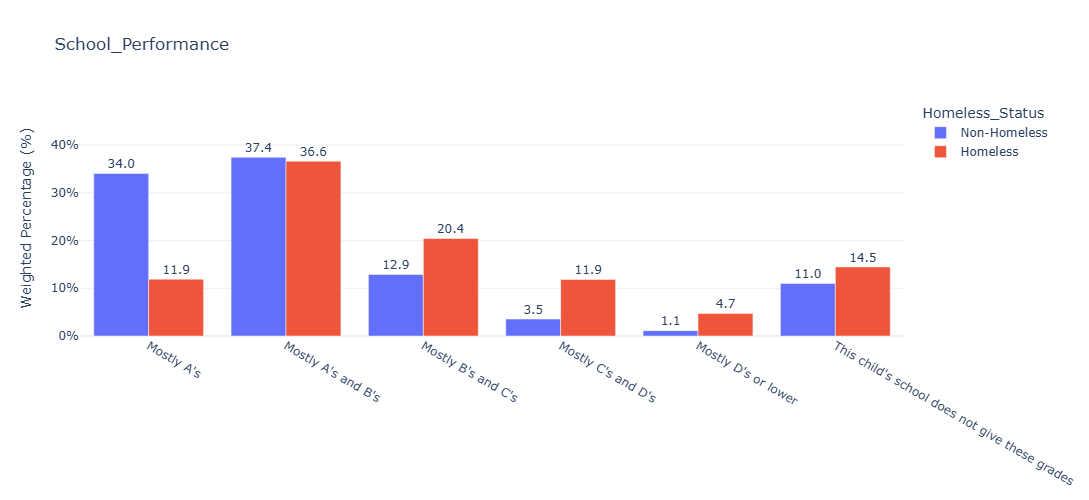

  Homeless_Status General_Health        Weight  Percentage
0        Homeless      Excellent  8.031721e+05   42.822986
1        Homeless           Fair  6.514570e+04    3.473395
2        Homeless           Good  3.614612e+05   19.272142
3        Homeless           Poor  1.671710e+04    0.891311
4        Homeless      Very Good  6.290670e+05   33.540167
5    Non-Homeless      Excellent  4.364711e+07   64.765509
6    Non-Homeless           Fair  7.662285e+05    1.136964
7    Non-Homeless           Good  5.605176e+06    8.317208
8    Non-Homeless           Poor  1.022916e+05    0.151785
9    Non-Homeless      Very Good  1.727171e+07   25.628534
General_Health   Excellent  Fair  Good  Poor  Very Good
Homeless_Status                                        
Homeless               430    35   198     9        337
Non-Homeless         32004   506  3570    72      12462

Chi-Square Statistic: 387.88

p-value: 1.15e-82


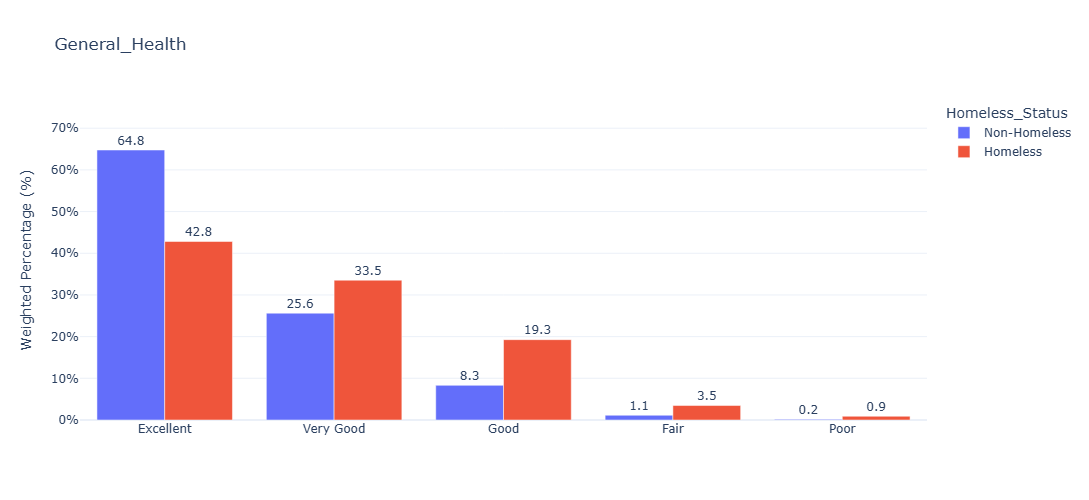

   Homeless_Status                                        Child_Race  \
0         Homeless            American Indian or Alaska Native Alone   
1         Homeless                                       Asian Alone   
2         Homeless                   Black or African American Alone   
3         Homeless  Native Hawaiian and Other Pacific Islander Alone   
4         Homeless                                 Two or More Races   
5         Homeless                                       White Alone   
6     Non-Homeless            American Indian or Alaska Native Alone   
7     Non-Homeless                                       Asian Alone   
8     Non-Homeless                   Black or African American Alone   
9     Non-Homeless  Native Hawaiian and Other Pacific Islander Alone   
10    Non-Homeless                                 Two or More Races   
11    Non-Homeless                                       White Alone   

          Weight  Percentage  
0   3.361803e+04    1.775976  
1

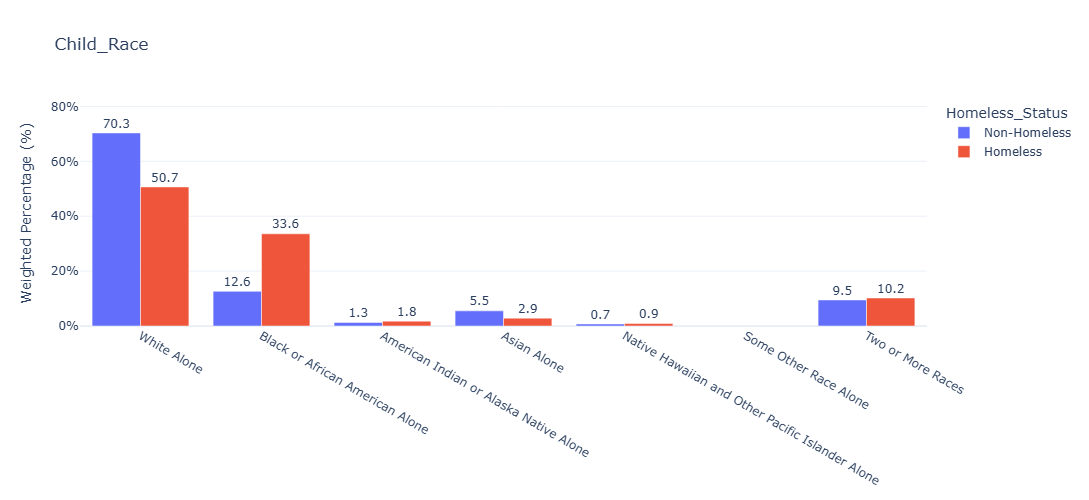

  Homeless_Status Primary Language Spoken at Home / English Ability  \
0        Homeless                                           English   
1        Homeless                                    Other Language   
2        Homeless                                           Spanish   
3    Non-Homeless                                           English   
4    Non-Homeless                                    Other Language   
5    Non-Homeless                                           Spanish   

         Weight  Percentage  
0  1.358393e+06   83.240970  
1  4.873945e+04    2.986704  
2  2.247479e+05   13.772326  
3  4.674187e+07   89.546329  
4  1.248096e+06    2.391056  
5  4.208566e+06    8.062615  
Primary Language Spoken at Home / English Ability  English  Other Language  \
Homeless_Status                                                              
Homeless                                               802              25   
Non-Homeless                                         36732

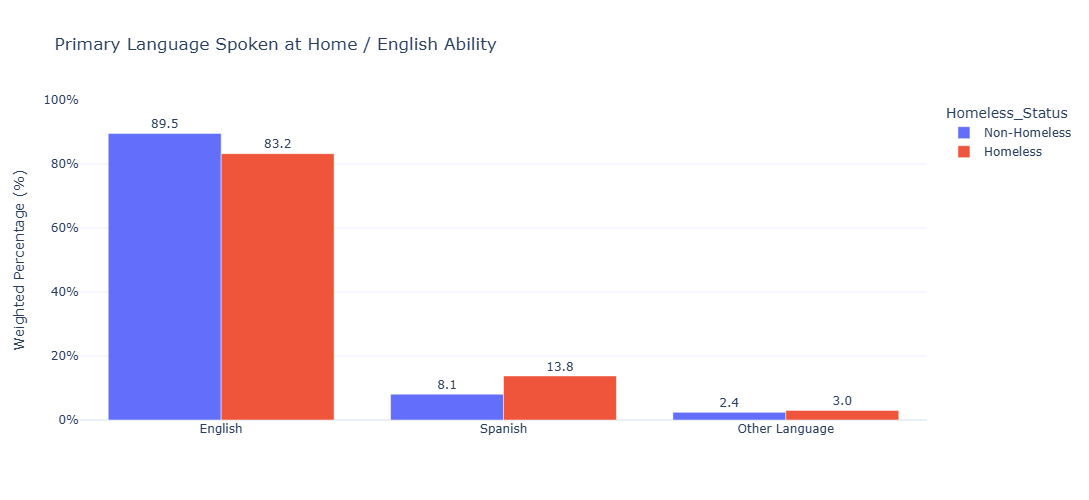

  Homeless_Status Was Selected Child Born in the US?        Weight  Percentage
0        Homeless                                 No  1.836634e+05     9.74034
1        Homeless                                Yes  1.701932e+06    90.25966
2    Non-Homeless                                 No  3.512582e+06     5.21903
3    Non-Homeless                                Yes  6.379078e+07    94.78097
Was Selected Child Born in the US?    No    Yes
Homeless_Status                                
Homeless                              67    942
Non-Homeless                        1543  47029

Chi-Square Statistic: 36.65

p-value: 1.42e-09


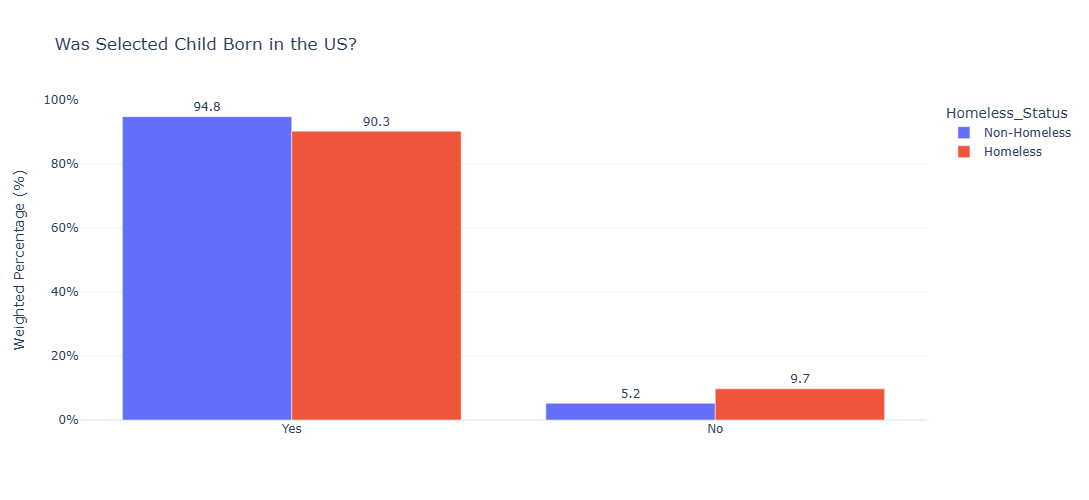

  Homeless_Status Hispanic, Latino, or Spanish origin?        Weight  \
0        Homeless                                   No  1.324894e+06   
1        Homeless                                  Yes  5.680398e+05   
2    Non-Homeless                                   No  4.930169e+07   
3    Non-Homeless                                  Yes  1.832980e+07   

   Percentage  
0   69.991560  
1   30.008440  
2   72.897541  
3   27.102459  
Hispanic, Latino, or Spanish origin?     No   Yes
Homeless_Status                                  
Homeless                                799   215
Non-Homeless                          41507  7255

Chi-Square Statistic: 30.66

p-value: 3.08e-08


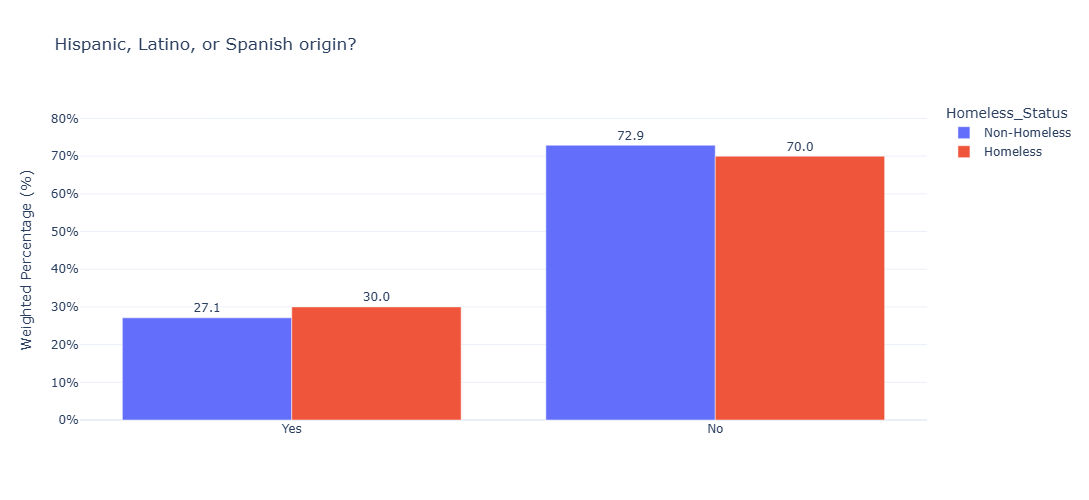

  Homeless_Status Cares About Doing Well in School        Weight  Percentage
0        Homeless                           Always  5.833014e+05   37.042648
1        Homeless                            Never  9.684673e+04    6.150267
2        Homeless                        Sometimes  3.964351e+05   25.175670
3        Homeless                          Usually  4.980921e+05   31.631415
4    Non-Homeless                           Always  2.626007e+07   56.759492
5    Non-Homeless                            Never  1.110845e+06    2.401022
6    Non-Homeless                        Sometimes  5.017810e+06   10.845680
7    Non-Homeless                          Usually  1.387679e+07   29.993806
Cares About Doing Well in School  Always  Never  Sometimes  Usually
Homeless_Status                                                    
Homeless                             314     63        206      301
Non-Homeless                       18889    860       4160    11282

Chi-Square Statistic: 222.31

p-va

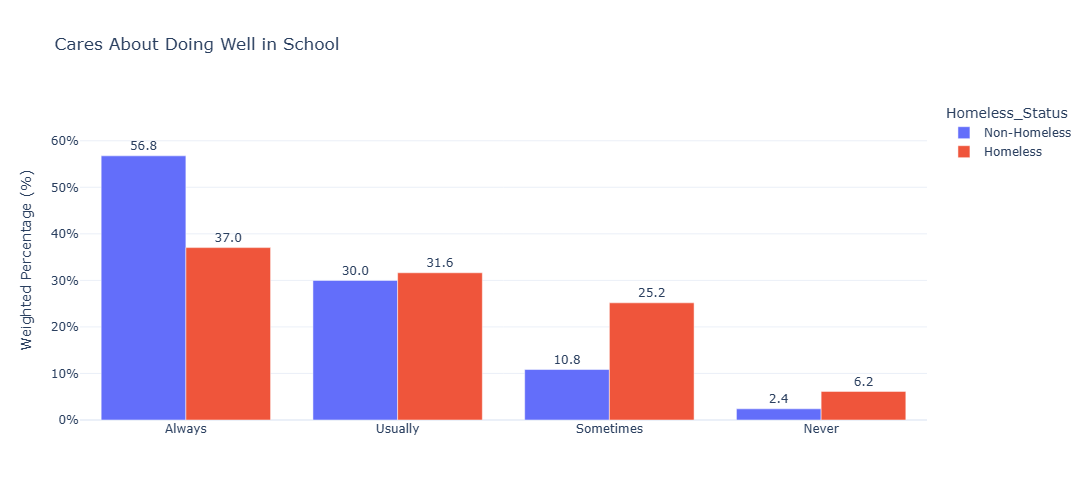

  Homeless_Status Does All Required Homework        Weight  Percentage
0        Homeless                     Always  4.893449e+05   31.295713
1        Homeless                      Never  1.030559e+05    6.590867
2        Homeless                  Sometimes  3.933308e+05   25.155197
3        Homeless                    Usually  5.778848e+05   36.958222
4    Non-Homeless                     Always  2.561399e+07   55.406794
5    Non-Homeless                      Never  8.620812e+05    1.864808
6    Non-Homeless                  Sometimes  5.139113e+06   11.116652
7    Non-Homeless                    Usually  1.461378e+07   31.611746
Does All Required Homework  Always  Never  Sometimes  Usually
Homeless_Status                                              
Homeless                       259     68        221      331
Non-Homeless                 18337    747       4060    12014

Chi-Square Statistic: 341.41

p-value: 1.08e-73


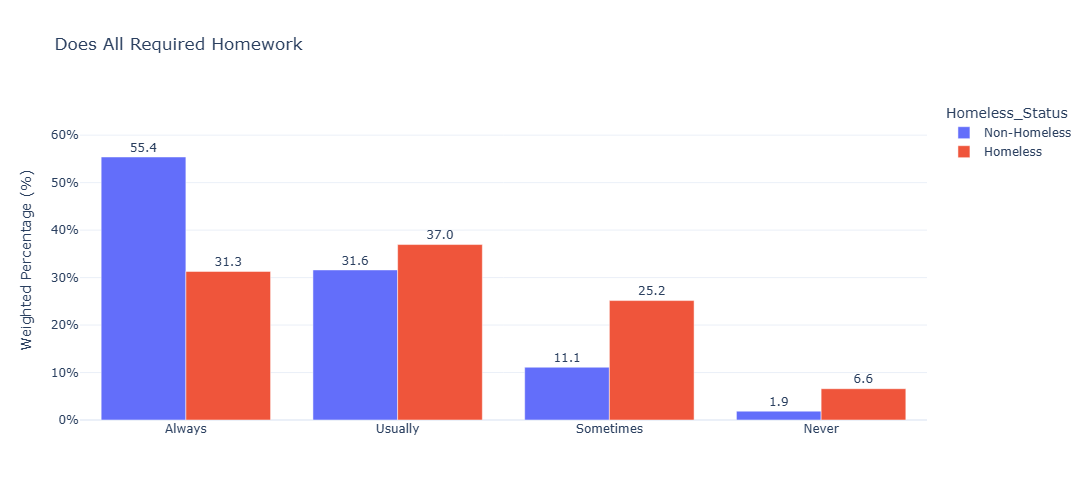

In [110]:
for i in value_maps:
    if i != 'Homeless_Status':
        plotfeature(df=colmap, feature=i, title=i)